In [20]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/amaymishra11/student-placement-and-salary-dataset-skills-based/student_placement_salary_elite_v2.csv


In [21]:
df=pd.read_csv("/kaggle/input/datasets/amaymishra11/student-placement-and-salary-dataset-skills-based/student_placement_salary_elite_v2.csv")
df

,student_id,cgpa,branch,college_tier,python_skill,dsa_skill,ml_skill,web_dev_skill,coding_score,communication_score,aptitude_score,internships,projects,backlogs,resume_score,skill_score,placed,company_type,job_role,salary_lpa
0,S0,6.87,Civil,1,1,1,0,0,15.6,4.3,92.0,1,3,0,62.6,2,1,MNC,Software Engineer,63.55
1,S1,6.52,Civil,2,1,0,0,1,13.9,5.8,62.0,1,6,0,77.5,2,1,MNC,Data Scientist,75.17
2,S2,5.33,IT,1,1,1,1,0,9.8,8.1,66.4,0,5,1,76.0,3,1,MNC,Software Engineer,80.44
3,S3,6.04,Civil,3,1,0,1,0,39.5,9.6,83.6,0,6,0,74.3,2,1,MNC,Software Engineer,72.11
4,S4,6.78,Mechanical,2,0,1,0,1,7.5,9.9,86.3,0,3,0,66.8,2,1,Mid-size,Software Engineer,67.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8995,S8995,6.51,IT,2,1,0,0,1,56.6,8.2,43.2,0,2,0,50.1,2,1,MNC,Analyst,75.29
8996,S8996,7.74,IT,3,1,1,1,0,67.9,6.3,49.4,0,2,0,57.6,3,1,MNC,Analyst,69.30
8997,S8997,7.14,CSE,3,1,0,1,1,40.4,8.0,67.4,1,1,0,65.8,3,1,MNC,Data Scientist,85.58
8998,S8998,5.21,IT,1,1,0,0,1,79.9,6.3,77.2,1,6,0,78.9,2,1,Mid-size,Software Engineer,54.54


In [22]:
corr = df.corr(numeric_only=True)
corr

,cgpa,college_tier,python_skill,dsa_skill,ml_skill,web_dev_skill,coding_score,communication_score,aptitude_score,internships,projects,backlogs,resume_score,skill_score,placed,salary_lpa
cgpa,1.000000,0.000108,-0.008449,0.001222,-0.003027,0.000701,0.003648,0.006023,-0.011885,-0.005721,0.008058,-0.014016,0.001840,-0.004687,0.095778,0.097705
college_tier,0.000108,1.000000,0.004296,-0.004069,0.008662,-0.000474,-0.005037,-0.015204,-0.006763,0.006130,-0.006845,-0.004119,-0.004393,0.003950,-0.207083,-0.166199
python_skill,-0.008449,0.004296,1.000000,-0.020889,-0.007627,0.003318,-0.010996,0.004395,0.010485,-0.010907,-0.002695,0.003673,0.266204,0.487595,0.143134,0.288744
dsa_skill,0.001222,-0.004069,-0.020889,1.000000,-0.013123,-0.001475,-0.014913,0.009201,-0.022263,-0.008563,0.011684,-0.006185,0.285557,0.503888,0.147735,0.296642
ml_skill,-0.003027,0.008662,-0.007627,-0.013123,1.000000,0.008185,0.004548,0.005092,-0.003858,-0.019664,0.010155,-0.002518,0.262484,0.474289,0.127094,0.253923
web_dev_skill,0.000701,-0.000474,0.003318,-0.001475,0.008185,1.000000,-0.004285,0.009168,0.006442,0.011462,-0.002860,-0.007592,0.293537,0.517429,0.140937,0.290097
coding_score,0.003648,-0.005037,-0.010996,-0.014913,0.004548,-0.004285,1.000000,-0.013045,0.002485,-0.013011,0.013485,-0.010994,-0.012733,-0.013289,0.207325,0.213842
communication_score,0.006023,-0.015204,0.004395,0.009201,0.005092,0.009168,-0.013045,1.000000,0.023579,-0.012749,-0.011793,0.015241,0.295682,0.014144,0.119618,0.113370
aptitude_score,-0.011885,-0.006763,0.010485,-0.022263,-0.003858,0.006442,0.002485,0.023579,1.000000,-0.008738,-0.000529,-0.021573,-0.000254,-0.004913,0.076450,0.054091
internships,-0.005721,0.006130,-0.010907,-0.008563,-0.019664,0.011462,-0.013011,-0.012749,-0.008738,1.000000,-0.003311,0.012107,0.557608,-0.013501,0.196917,0.177142


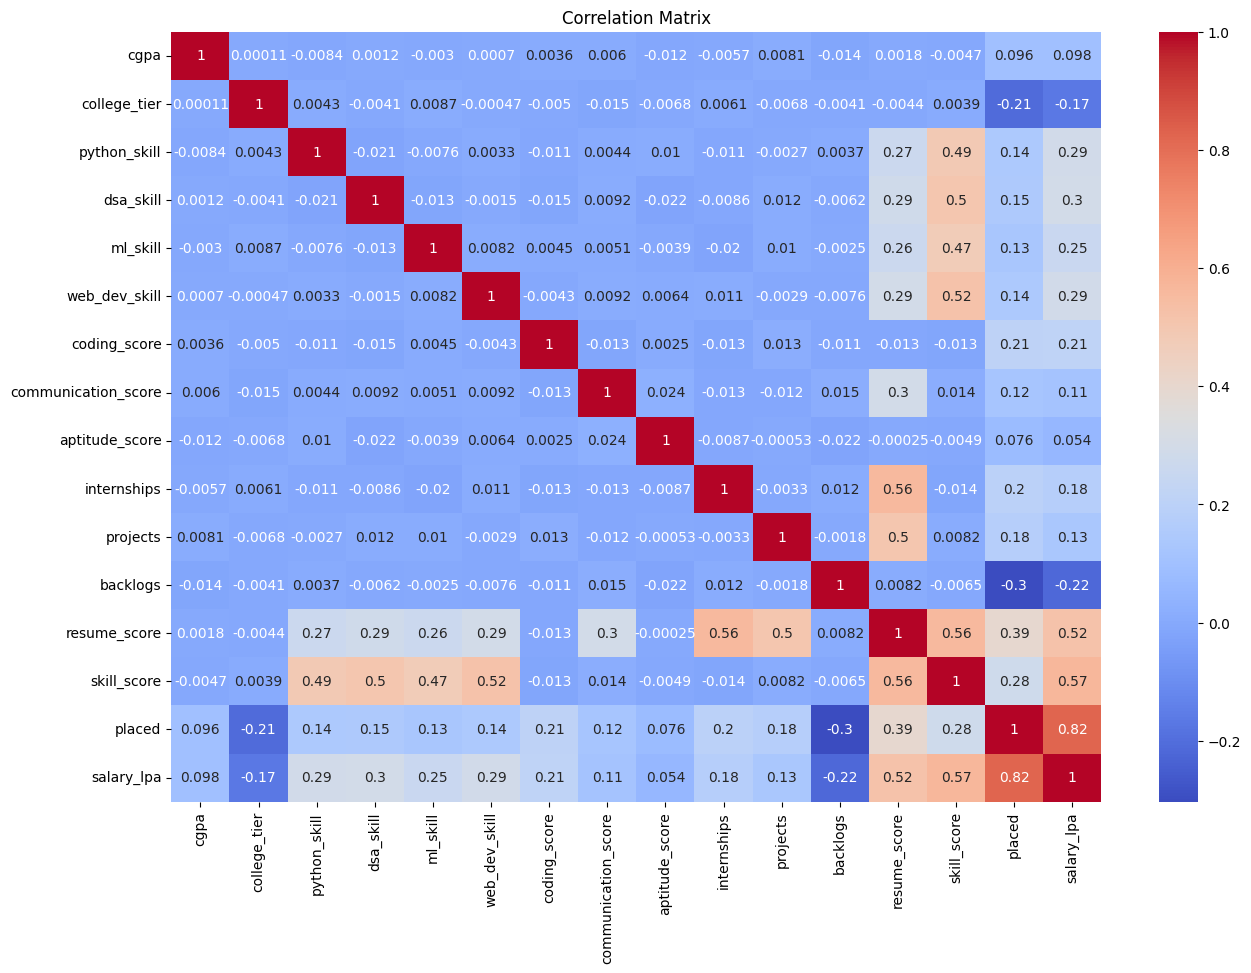

In [24]:
plt.figure(figsize=(15,10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

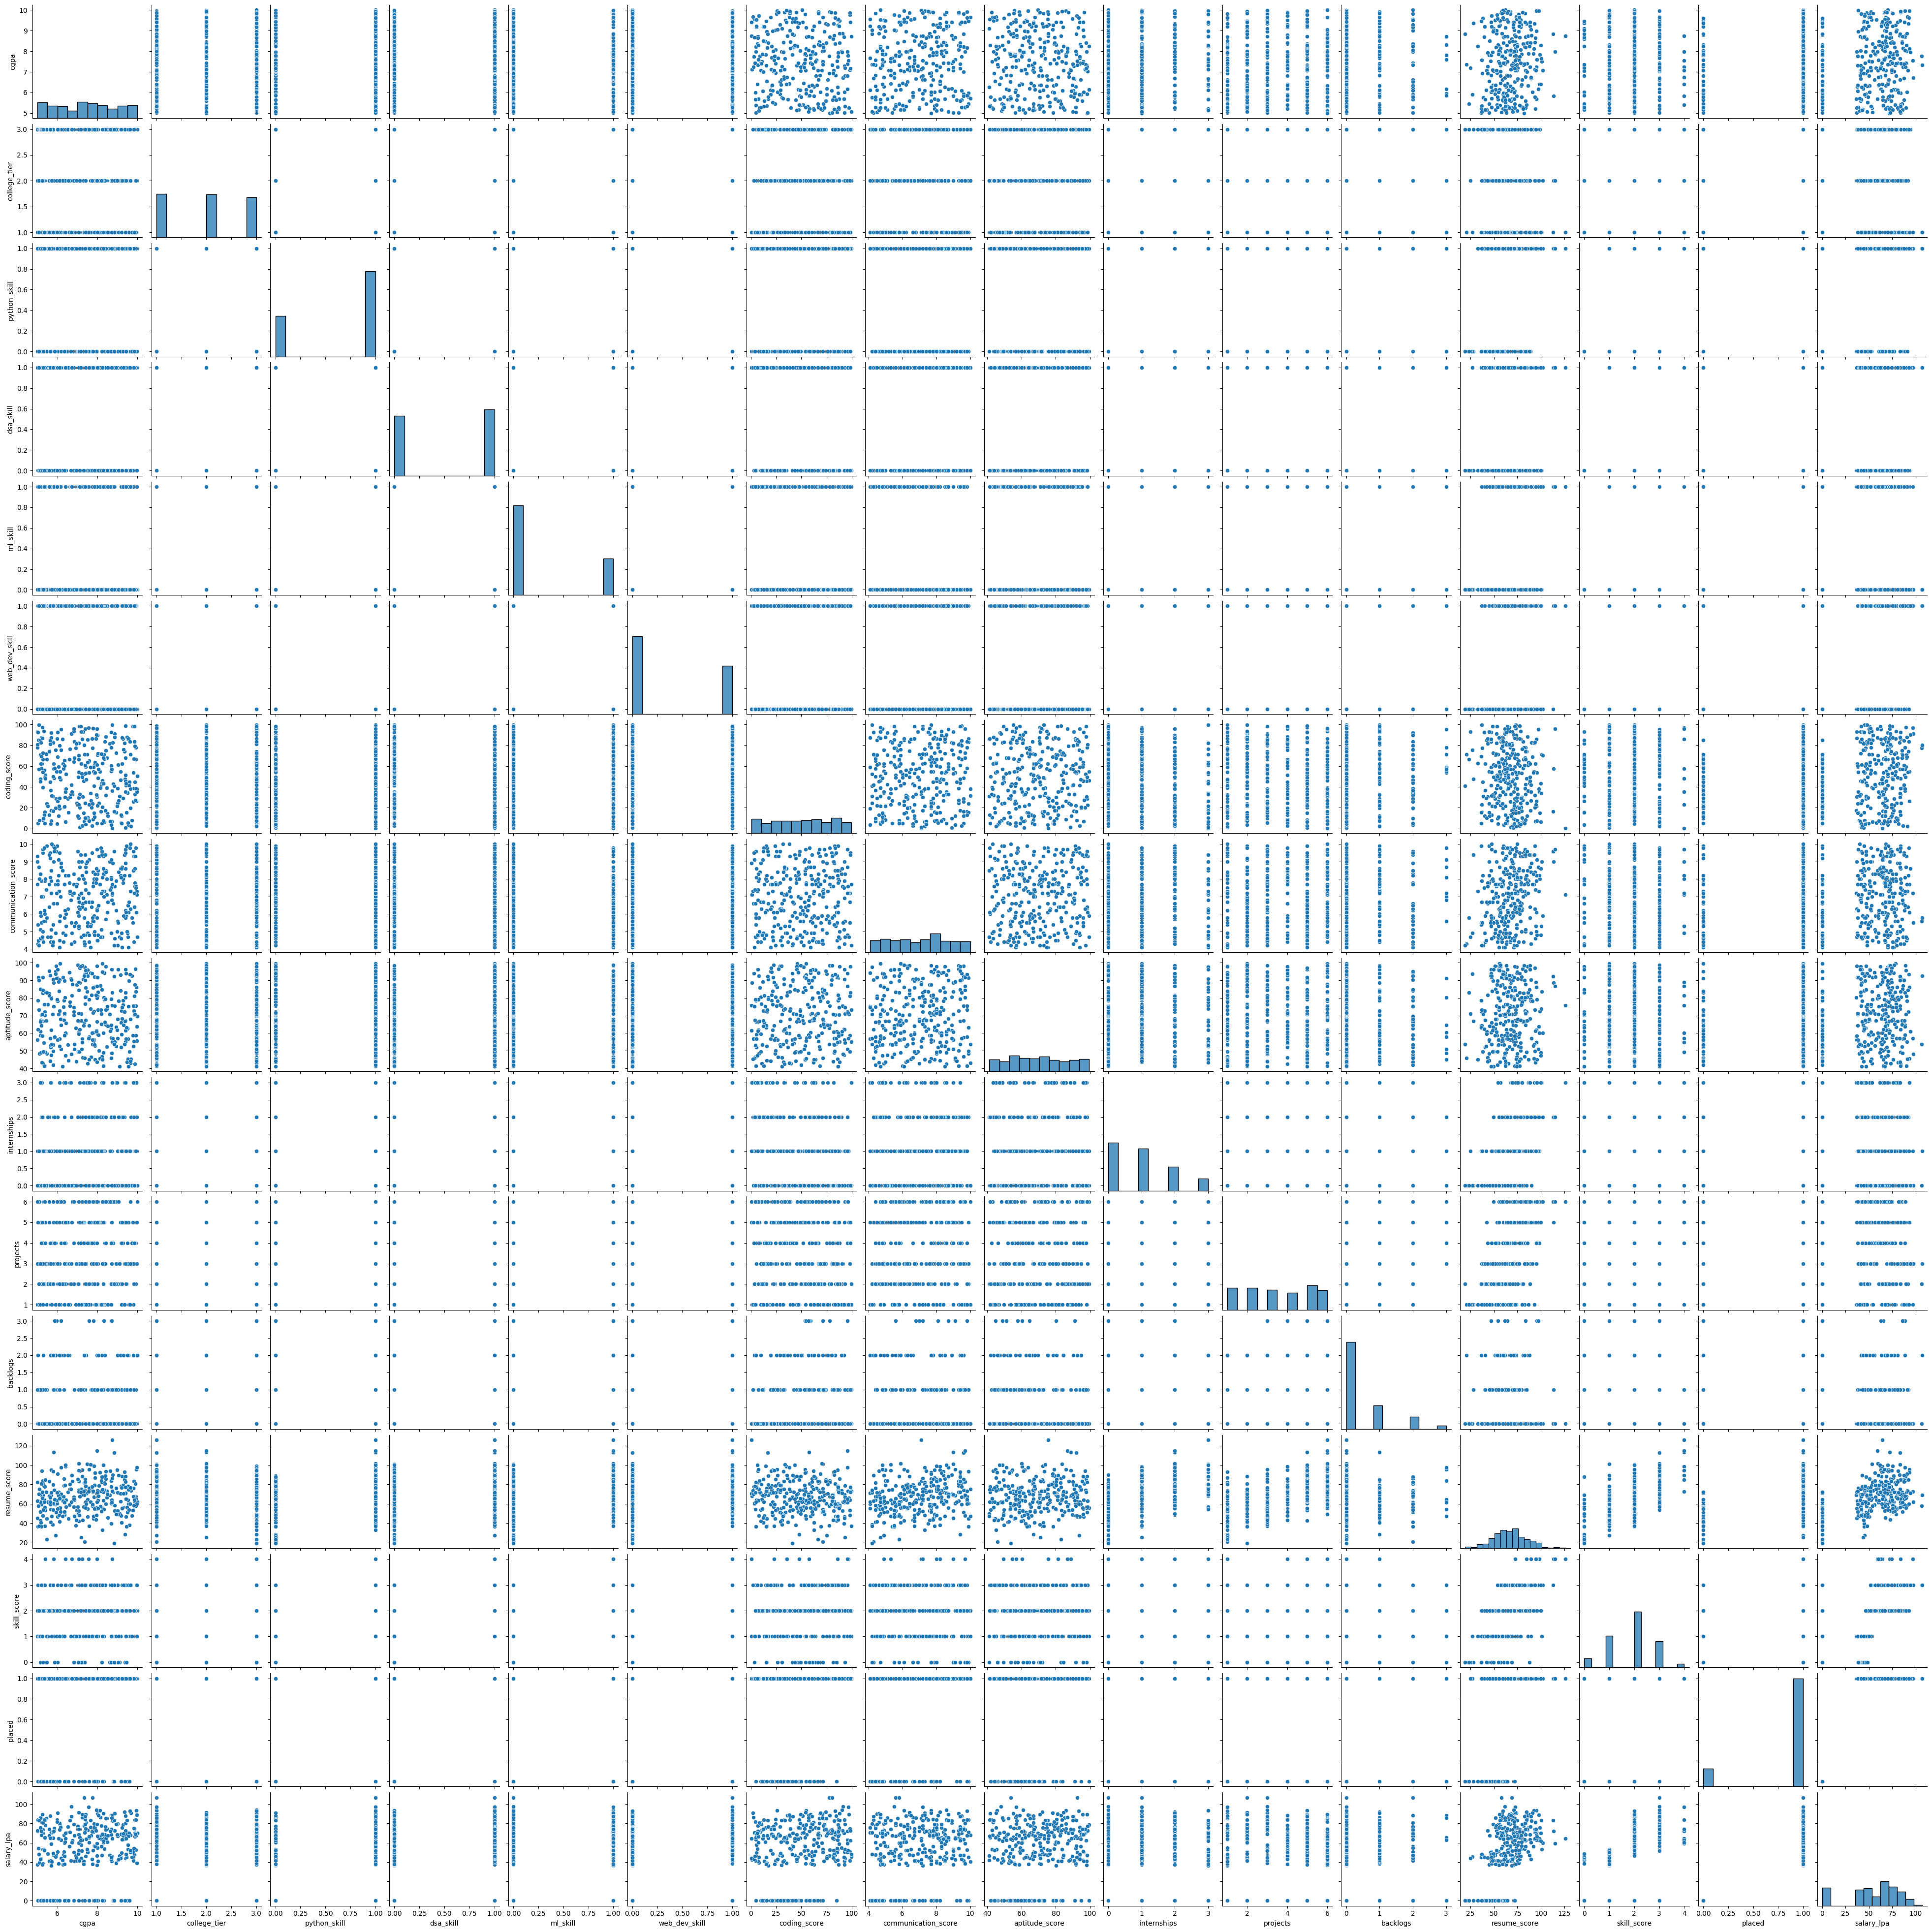

In [26]:
sns.pairplot(df.sample(300))
plt.show()

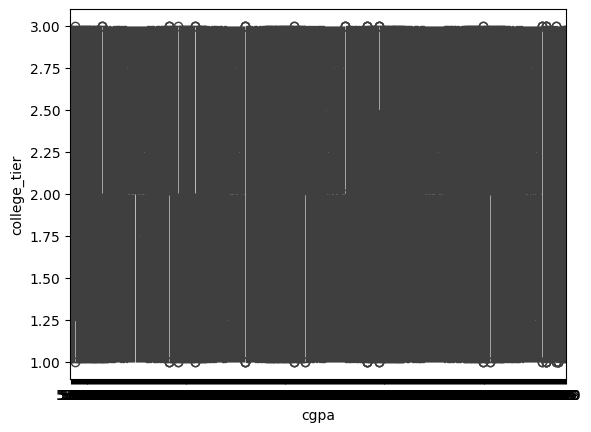

In [29]:
sns.boxplot(x="cgpa",y="college_tier",data=df)
plt.show()

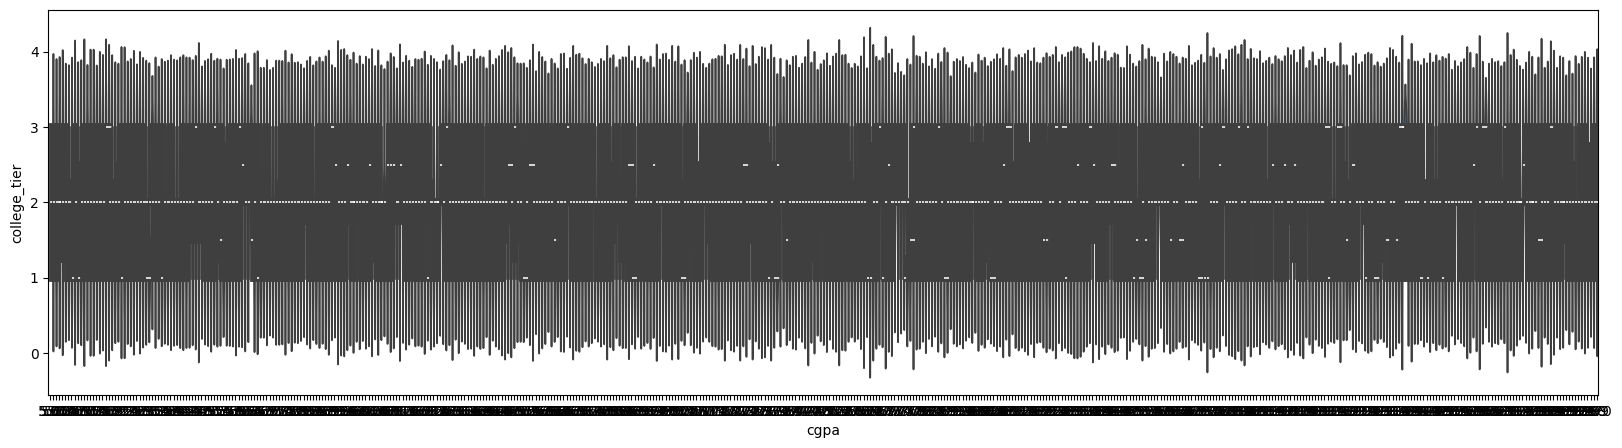

In [36]:
plt.figure(figsize=(20,5))
sns.violinplot(x="cgpa",y="college_tier",data=df)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

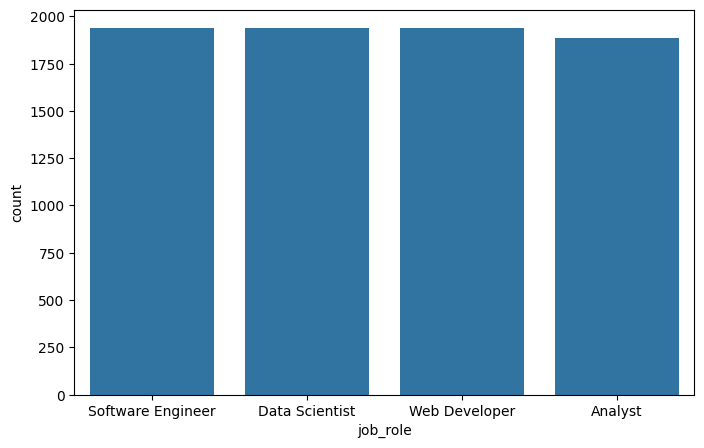

In [34]:
plt.figure(figsize=(8,5))
sns.countplot(x="job_role",data=df)
plt.show